    ECM-1_setpoint_19C -> common O&M-1
    ECM-3_setpoint_19C_reschedule_8_8_8 -> common O&M-2
    ECM-2_reschedule_8_8_8 -> common O&M-3
    ECM-5_reschedule_8_8_8_default_infiltration -> common O&M-4

    E+ O&M-1 -> common O&M-1
    E+ O&M-2 -> common O&M-2
    E+ O&M-3 -> common O&M-3
    E+ O&M-5 -> common O&M-4

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'Arial',"mathtext.fontset": "stix",
    'font.size': 14,
    'axes.labelsize': 18,
    'legend.fontsize': 12,
})

# ============================================================
# 1. Paths
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")

eplus_ecm_path = (
    pred_dir / "ecm_savings_daily_EPlus_4P_FEBMAR_LoD1to3.csv"
)

rc_run_ids = [
    "ETHlib_default_occ",
    "ETHlib_ONSITE_occ",
    "ETHlib_bldg_LoD_Y",
    "ETHlib_3R2C_default_occ",
    "ETHlib_3R2C_ONSITE_occ",
    "ETHlib_3R2C_bldg_LoD_Y",
]


# ============================================================
# 2. Harmonisation maps
# ============================================================

quality_map = {
    # E+
    "beta": "LoD-1",
    "gamma": "LoD-2",
    "yearly": "LoD-3",
    "_beta": "LoD-1",
    "_gamma": "LoD-2",
    "bY": "LoD-3",

    # RC
    "default_occ": "LoD-1",
    "ONSITE_occ": "LoD-2",
    "bldg_LoD_Y": "LoD-3",
}

quality_label_map = {
    "LoD-1": r"LoD-1",
    "LoD-2": r"LoD-2",
    "LoD-3": r"LoD-3",
}

eplus_ecm_to_common = {
    "O&M-1": "O&M-1",
    "O&M-2": "O&M-2",
    "O&M-3": "O&M-3",
    "O&M-5": "O&M-4",

    # Keep these, but they may not have direct RC equivalents.
    "O&M-4": "E+ only: O&M-4",
    "O&M-6": "E+ only: O&M-6",
}

# RC exported ECM names -> common names
rc_ecm_to_common = {
    "ECM-1_setpoint_19C": "O&M-1",
    "ECM-3_setpoint_19C_reschedule_8_8_8": "O&M-2",
    "ECM-2_reschedule_8_8_8": "O&M-3",

    # This matches your note that E+ O&M-5 corresponds to RC O&M-4.
    "ECM-4_setpoint_19C_default_infiltration": "O&M-4",

    # Keep this separately because it is not clearly one of the four common ECMs.
    "ECM-5_reschedule_8_8_8_default_infiltration": "RC only: setpoint + default infiltration",
}

ecm_label_map = {
    "O&M-1": "ECM-1:\nHeating setpoint change",
    "O&M-2": "ECM-2:\nHeating setpoint change & scheduling",
    "O&M-3": "ECM-3:\nHeating scheduling",
    "O&M-4": "ECM-4:\nHeating setpoint change\n+ Reduced window opening",
    "E+ only: O&M-4": "E+ only:\nO&M-4",
    "E+ only: O&M-6": "E+ only:\nO&M-6",
    "RC only: setpoint + default infiltration": "RC only:\Setpoint change\n+ Reduced window opening",
}

common_ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]


# ============================================================
# 3. Load E+ ECM savings
# ============================================================

def load_eplus_ecm_savings(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing E+ ECM savings file: {path}")

    df = pd.read_csv(path)

    if "scenario" not in df.columns:
        raise ValueError("E+ file needs a 'scenario' column.")

    if "ecm" not in df.columns:
        raise ValueError("E+ file needs an 'ecm' column.")

    df["source"] = "EPlus"
    df["engine"] = "EnergyPlus"
    df["model_name"] = "EnergyPlus"

    df["data_quality"] = df["scenario"].map(quality_map)

    if "scenario_group" in df.columns:
        df["data_quality"] = df["data_quality"].fillna(
            df["scenario_group"].map(quality_map)
        )

    df["ecm_common"] = df["ecm"].map(eplus_ecm_to_common).fillna(df["ecm"])
    df["ecm_label"] = df["ecm_common"].map(ecm_label_map).fillna(df["ecm_common"])

    return df


# ============================================================
# 4. Load RC ECM savings
# ============================================================

def infer_rc_model_name(run_label):
    if "ETHlib_3R2C" in run_label:
        return "3R2C"
    if "ETHlib" in run_label:
        return "5R1C"
    return "RC"


def infer_rc_scenario_group(run_label):
    if "default_occ" in run_label:
        return "default_occ"
    if "ONSITE_occ" in run_label:
        return "ONSITE_occ"
    if "bldg_LoD_Y" in run_label:
        return "bldg_LoD_Y"
    return "unknown"


def load_rc_ecm_savings(base_date, rc_run_ids):
    dfs = []
    missing = []

    for run_id in rc_run_ids:
        run_label = f"{base_date}__{run_id}"

        path = (
            Path(f"_json/_run/{run_label}")
            / "_outcome"
            / run_label
            / "ecm_savings_daily.csv"
        )

        if not path.exists():
            missing.append(path)
            continue

        df = pd.read_csv(path)

        scenario_group = infer_rc_scenario_group(run_label)
        model_name = infer_rc_model_name(run_label)

        df["source"] = "RC"
        df["engine"] = model_name
        df["model_name"] = model_name
        df["experiment_id"] = run_label
        df["scenario"] = scenario_group
        df["scenario_group"] = scenario_group
        df["data_quality"] = quality_map.get(scenario_group, "unknown")

        if "ecm" not in df.columns:
            raise ValueError(f"RC file has no 'ecm' column: {path}")

        df["ecm_common"] = df["ecm"].map(rc_ecm_to_common).fillna(df["ecm"])
        df["ecm_label"] = df["ecm_common"].map(ecm_label_map).fillna(df["ecm_common"])

        if "saving_frac" not in df.columns and "saving_rel" in df.columns:
            df["saving_frac"] = df["saving_rel"] / 100.0

        dfs.append(df)

    if missing:
        print("[WARN] Missing RC ECM files:")
        for p in missing:
            print("   ", p)

    if not dfs:
        raise ValueError("No RC ECM savings files were loaded.")

    return pd.concat(dfs, ignore_index=True)


# ============================================================
# 5. Combine and save
# ============================================================

ecm_eplus = load_eplus_ecm_savings(eplus_ecm_path)

ecm_rc = load_rc_ecm_savings(
    base_date=BASE_DATE,
    rc_run_ids=rc_run_ids,
)

ecm_savings_all = pd.concat(
    [ecm_eplus, ecm_rc],
    ignore_index=True,
)

# Keep only common comparable ECMs and LoD-1 to LoD-3
ecm_savings_common = ecm_savings_all[
    ecm_savings_all["ecm_common"].isin(common_ecm_order)
    & ecm_savings_all["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
].copy()

ecm_savings_common["ecm_label"] = pd.Categorical(
    ecm_savings_common["ecm_label"],
    categories=[ecm_label_map[x] for x in common_ecm_order],
    ordered=True,
)

ecm_savings_common["data_quality"] = pd.Categorical(
    ecm_savings_common["data_quality"],
    categories=["LoD-1", "LoD-2", "LoD-3"],
    ordered=True,
)

ecm_savings_common["engine"] = pd.Categorical(
    ecm_savings_common["engine"],
    categories=["EnergyPlus", "5R1C", "3R2C"],
    ordered=True,
)

display(
    ecm_savings_common.groupby(
        ["engine", "data_quality", "ecm_common"]
    )["sample_id"].nunique()
)

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42425/2771701236.py:247: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ecm_savings_common.groupby(


engine      data_quality  ecm_common
EnergyPlus  LoD-1         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-2         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-3         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
5R1C        LoD-1         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-2         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-3         O&M-1         10
                          O&M-2         10
                 

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42425/2757764969.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([quality_display_map[q] for q in quality_order])
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42425/2757764969.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([quality_display_map[q] for q in quality_order])
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42425/2757764969.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([quality_display_map[q] for q in quality_order])
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42425/2757764969.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of t

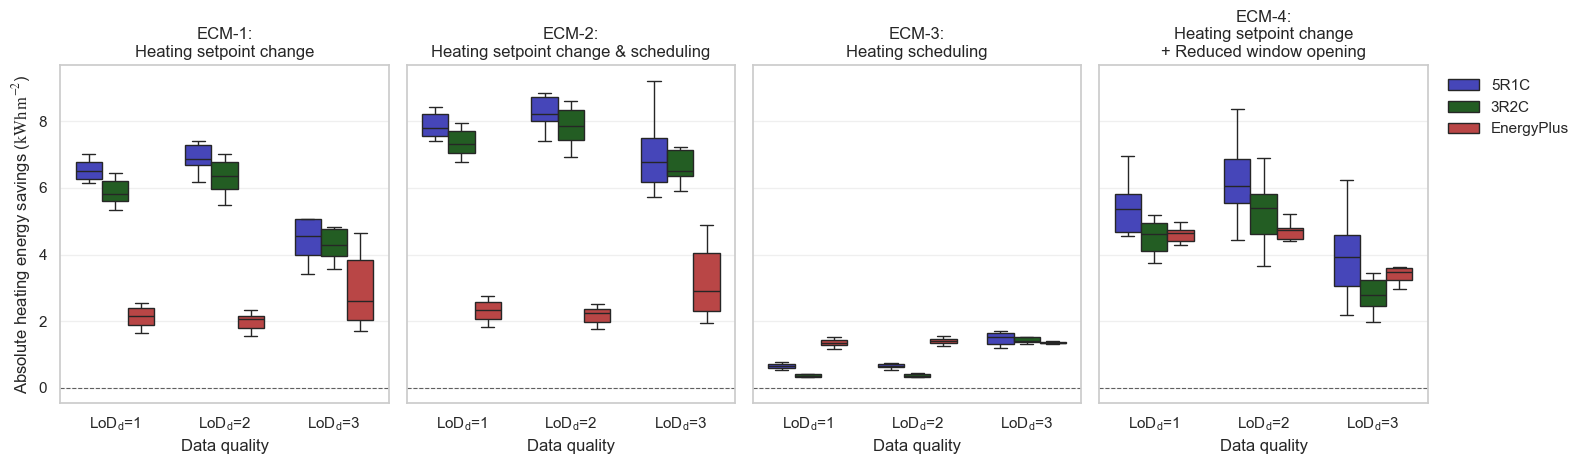

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42425/2757764969.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([quality_display_map[q] for q in quality_order])
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42425/2757764969.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([quality_display_map[q] for q in quality_order])
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42425/2757764969.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([quality_display_map[q] for q in quality_order])
/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42425/2757764969.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of t

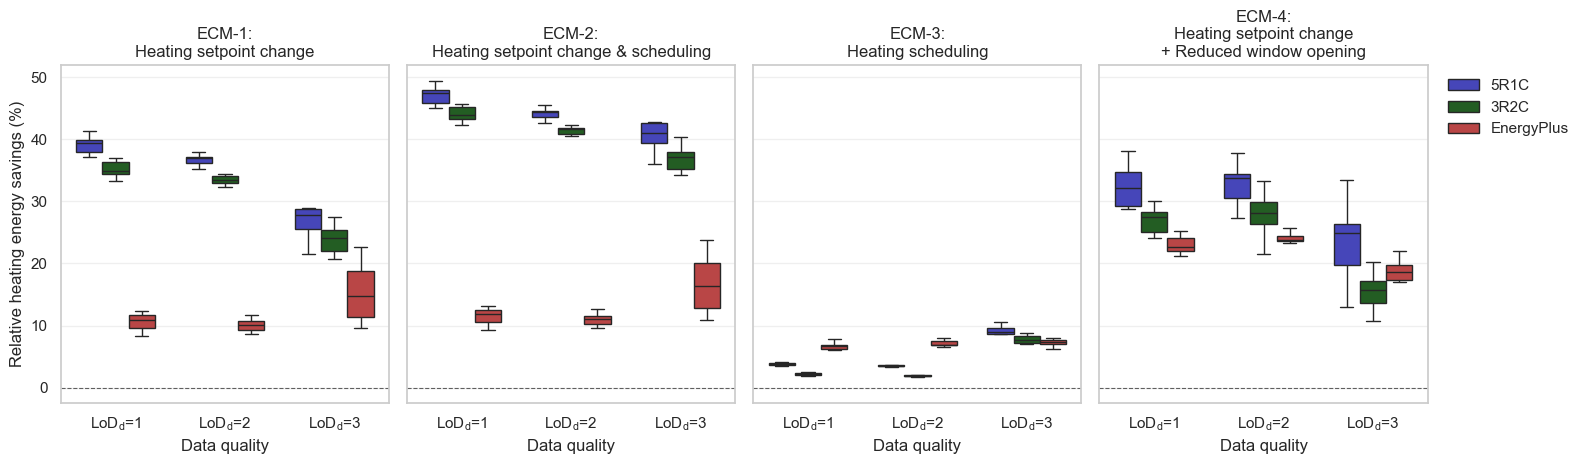

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams["text.usetex"] = False


engine_order = ["5R1C", "3R2C","EnergyPlus"]
quality_order = ["LoD-1", "LoD-2", "LoD-3"]
common_ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]

quality_display_map = {
    "LoD-1": r"$\mathregular{LoD}_{\mathregular{d}}$=1",
    "LoD-2": r"$\mathregular{LoD}_{\mathregular{d}}$=2",
    "LoD-3": r"$\mathregular{LoD}_{\mathregular{d}}$=3",
}

engine_palette = {
    "EnergyPlus": "red",
    "5R1C": "blue",
    "3R2C": "green",
}


plot_df = ecm_savings_common.copy()

plot_df = plot_df[
    plot_df["ecm_common"].isin(common_ecm_order)
    & plot_df["engine"].isin(engine_order)
    & plot_df["data_quality"].isin(quality_order)
].copy()

plot_df["saving_frac_pct"] = plot_df["saving_frac"] * 100.0

plot_df["ecm_common"] = pd.Categorical(
    plot_df["ecm_common"],
    categories=common_ecm_order,
    ordered=True,
)

plot_df["data_quality"] = pd.Categorical(
    plot_df["data_quality"],
    categories=quality_order,
    ordered=True,
)

plot_df["engine"] = pd.Categorical(
    plot_df["engine"],
    categories=engine_order,
    ordered=True,
)


def plot_ecm_saving_boxplots(
    plot_df,
    y_var,
    y_label,
):
    fig, axes = plt.subplots(
        1,
        len(common_ecm_order),
        figsize=(16, 4.8),
        sharey=True,
    )

    for ax, ecm in zip(axes, common_ecm_order):
        d = plot_df[plot_df["ecm_common"] == ecm].copy()

        sns.boxplot(
            data=d,
            x="data_quality",
            y=y_var,
            hue="engine",
            order=quality_order,
            hue_order=engine_order,
            palette=engine_palette,
            showfliers=False,
            linewidth=1,
            width=0.72,
            saturation=0.45,
            ax=ax,
        )

        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
            linestyle="--",
            alpha=0.6,
        )

        ax.set_title(ecm_label_map[ecm])
        ax.set_xlabel("Data quality")
        ax.set_xticklabels([quality_display_map[q] for q in quality_order])
        ax.grid(True, axis="y", alpha=0.3)

        if ax is axes[0]:
            ax.set_ylabel(y_label)
        else:
            ax.set_ylabel("")

        ax.get_legend().remove()

        for tick in ax.get_xticklabels():
            tick.set_multialignment("center")
            tick.set_linespacing(1.05)

    handles, labels = axes[-1].get_legend_handles_labels()

    axes[-1].legend(
        handles,
        labels,
        title="",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
    )

    plt.tight_layout()
    plt.show()

    return fig, axes


fig_abs, axes_abs = plot_ecm_saving_boxplots(
    plot_df=plot_df,
    y_var="saving_abs",
    y_label=(
        r"Absolute heating energy savings "
        r"($\mathrm{kWh\,m^{-2}}$)"
    ),

)


fig_rel, axes_rel = plot_ecm_saving_boxplots(
    plot_df=plot_df,
    y_var="saving_frac_pct",
    y_label=r"Relative heating energy savings (%)",
)

# RANKING BASED PLOTS

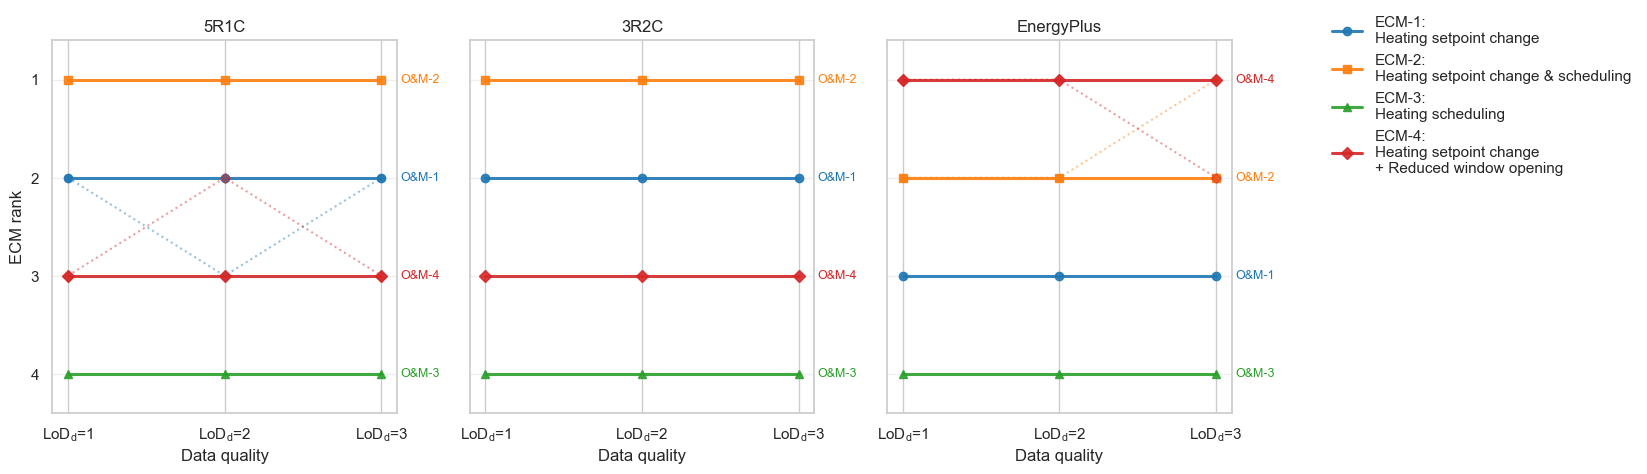

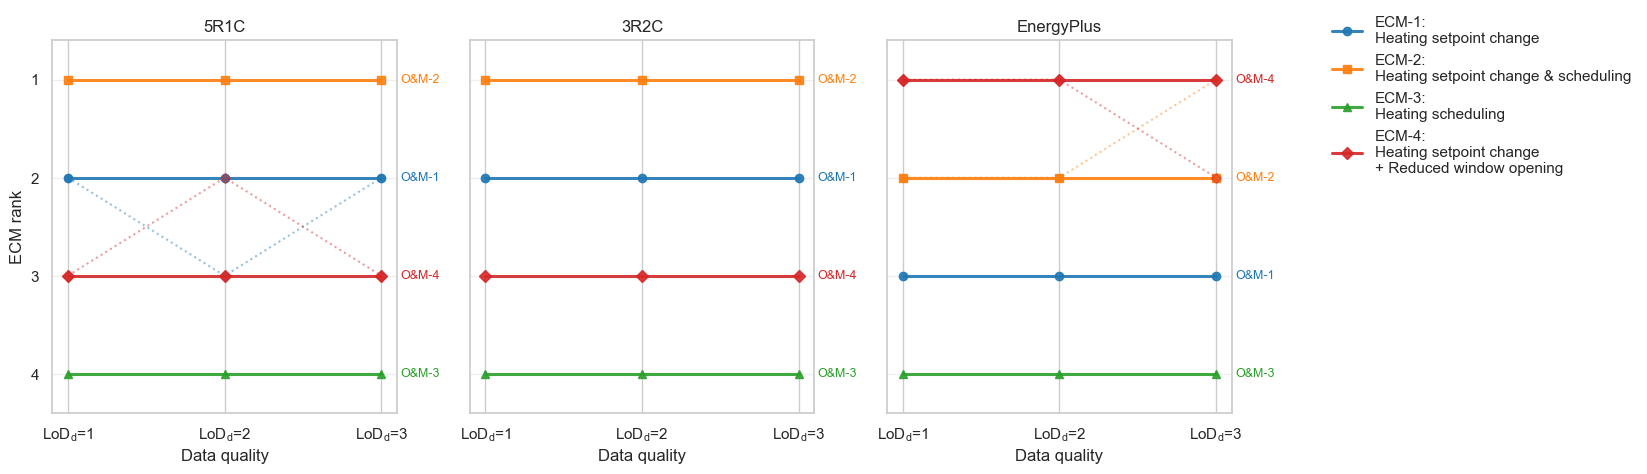

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_ecm_bump_chart_with_rank_uncertainty(
    ecm_savings_common,
    value_col="saving_abs",
    title="ECM ranking by heating-energy saving",
    show_q05=True,
    show_q95=True,
):
    engine_order = ["5R1C", "3R2C","EnergyPlus"]
    quality_order = ["LoD-1", "LoD-2", "LoD-3"]
    common_ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]


    df = ecm_savings_common.copy()

    df = df[
        df["engine"].isin(engine_order)
        & df["data_quality"].isin(quality_order)
        & df["ecm_common"].isin(common_ecm_order)
    ].copy()

    # ------------------------------------------------------------
    # Summarise q05, median and q95
    # ------------------------------------------------------------

    rank_df = (
        df
        .groupby(["engine", "data_quality", "ecm_common"], observed=True)
        .agg(
            q05=(value_col, lambda x: x.quantile(0.05)),
            q50=(value_col, "median"),
            q95=(value_col, lambda x: x.quantile(0.95)),
            n_samples=("sample_id", "nunique"),
        )
        .reset_index()
    )

    # Larger saving = better rank
    for q in ["q05", "q50", "q95"]:
        rank_df[f"rank_{q}"] = (
            rank_df
            .groupby(["engine", "data_quality"], observed=True)[q]
            .rank(ascending=False, method="min")
        )

    rank_df["engine"] = pd.Categorical(
        rank_df["engine"],
        categories=engine_order,
        ordered=True,
    )

    rank_df["data_quality"] = pd.Categorical(
        rank_df["data_quality"],
        categories=quality_order,
        ordered=True,
    )

    rank_df["ecm_common"] = pd.Categorical(
        rank_df["ecm_common"],
        categories=common_ecm_order,
        ordered=True,
    )

    palette = dict(
        zip(
            common_ecm_order,
            sns.color_palette("tab10", n_colors=len(common_ecm_order)),
        )
    )

    marker_map = {
        "O&M-1": "o",
        "O&M-2": "s",
        "O&M-3": "^",
        "O&M-4": "D",
    }

    x = np.arange(len(quality_order))
    x_labels = [quality_display_map[q] for q in quality_order]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(13, 4.8),
        sharey=True,
    )

    for ax, engine in zip(axes, engine_order):
        d_engine = rank_df[rank_df["engine"] == engine].copy()

        for ecm in common_ecm_order:
            d = (
                d_engine[d_engine["ecm_common"] == ecm]
                .set_index("data_quality")
                .reindex(quality_order)
                .reset_index()
            )

            y50 = d["rank_q50"].to_numpy()
            y05 = d["rank_q05"].to_numpy()
            y95 = d["rank_q95"].to_numpy()

            color = palette[ecm]
            marker = marker_map[ecm]

            # Median rank: main bump-chart line
            ax.plot(
                x,
                y50,
                marker=marker,
                linewidth=2.2,
                markersize=6,
                color=color,
                label=ecm_label_map[ecm],
                alpha=0.9,
            )

            # q05 rank: only show when it changes from median rank
            if show_q05 and not np.array_equal(y05, y50, equal_nan=True):
                ax.plot(
                    x,
                    y05,
                    marker=marker,
                    linewidth=1.5,
                    markersize=5,
                    color=color,
                    linestyle="--",
                    alpha=0.45,
                )

            # q95 rank: only show when it changes from median rank
            if show_q95 and not np.array_equal(y95, y50, equal_nan=True):
                ax.plot(
                    x,
                    y95,
                    marker=marker,
                    linewidth=1.5,
                    markersize=5,
                    color=color,
                    linestyle=":",
                    alpha=0.45,
                )

            # Add small ECM label at final LoD for the median line
            last_rank = y50[-1]
            if pd.notna(last_rank):
                ax.text(
                    x[-1] + 0.12,
                    last_rank,
                    ecm.replace("", ""),
                    va="center",
                    fontsize=9,
                    color=color,
                )

        ax.set_title(engine)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels)
        ax.set_xlabel("Data quality")
        ax.set_ylim(4.4, 0.6)
        ax.set_yticks([1, 2, 3, 4])
        ax.grid(True, axis="y", alpha=0.3)

    axes[0].set_ylabel("ECM rank")

    handles, labels = axes[0].get_legend_handles_labels()

    line_style_handles = [
        plt.Line2D([0], [0], color="black", linewidth=2.2, linestyle="-", label="Median rank"),
        plt.Line2D([0], [0], color="black", linewidth=1.5, linestyle="--", alpha=0.45, label="$q_{05}$ rank if changed"),
        plt.Line2D([0], [0], color="black", linewidth=1.5, linestyle=":", alpha=0.45, label="$q_{95}$ rank if changed"),
    ]

    fig.legend(
        handles,
        labels + [h.get_label() for h in line_style_handles],
        ncol=1,
        frameon=False,

        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )


    plt.tight_layout()
    plt.show()

    return fig, axes, rank_df

fig_abs, axes_abs, rank_abs_df = plot_ecm_bump_chart_with_rank_uncertainty(
    ecm_savings_common,
    value_col="saving_abs",
    title="",
)
fig_rel, axes_rel, rank_rel_df = plot_ecm_bump_chart_with_rank_uncertainty(
    ecm_savings_common,
    value_col="saving_rel",
    title="",
)